# TCN Classifier — Clasificación de Audio Raw (Parkinson)

Clasificación binaria **Control vs Patológicas** usando una **Temporal Convolutional Network (TCN)**
con activación WaveNet (tanh × sigmoid) aplicada directamente sobre la forma de onda.

---
## ¿Qué es un TCN y cómo funciona?

Un TCN es una red convolucional 1D con tres propiedades clave:

| Propiedad | Detalle |
|---|---|
| **Causalidad** | Padding `causal`: el modelo sólo ve el pasado, nunca el futuro |
| **Dilatación exponencial** | Cada bloque usa `dilation_rate = 2^k`, aumentando el campo receptivo sin más parámetros |
| **Conexiones residuales** | `salida = entrada + f(entrada)`, como ResNet, facilita el entrenamiento profundo |

### Activación WaveNet (gated activation)
```
gate = tanh(Conv1D_tanh(x))  ×  sigmoid(Conv1D_sigm(x))
```
- La rama **tanh** modula el *contenido* (valores entre −1 y 1)
- La rama **sigmoid** actúa como *puerta* (valores entre 0 y 1, controla cuánta información pasa)
- Permite al modelo aprender patrones temporales complejos similares a una LSTM, pero paralelizable.

### Campo receptivo efectivo
```
RF = 1 + (kernel_size − 1) × Σ(dilations) × nb_stacks
```
Con `kernel_size=3, dilations=[1,2,4,8,16,32], nb_stacks=1`:
```
RF = 1 + 2 × 63 × 1 = 127 muestras ≈ 7.9 ms @ 16 kHz
```
Con `nb_stacks=2` → RF = 253 muestras ≈ 15.8 ms.

### Arquitectura completa
```
Audio (8000,)
  → Reshape (8000, 1)
  → Conv1D 1×1  [proyección: 1 → nb_filters canales]
  → Bloque residual (dilation=1)   ──► skip_1
  → Bloque residual (dilation=2)   ──► skip_2
  → Bloque residual (dilation=4)   ──► skip_3
  → ...                             ...
  → Add(skip_1, skip_2, ...) → ReLU
  → GlobalAvgPool + GlobalMaxPool → Concat
  → Dense(32, relu) → Dropout
  → Dense(2, softmax)  [Control | Patológicas]
```

- **Modelo**: `src/models/TCNClassifier.py`
- **Splits**: Subject-wise K-Fold desde `data_splits.json`

In [16]:
import os
import sys
import json
import numpy as np
import librosa
from pathlib import Path
from tqdm import tqdm

import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    accuracy_score, ConfusionMatrixDisplay, RocCurveDisplay
)
import matplotlib.pyplot as plt

# ── Detectar raíz del proyecto ────────────────────────────────────────────────
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / 'data').exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
print(f"PROJECT_ROOT: {PROJECT_ROOT}")

# ── Importar TCNClassifier ────────────────────────────────────────────────────
sys.path.insert(0, str(PROJECT_ROOT / 'src' / 'models'))
from TCNClassifier import TCNClassifier

print(f"TensorFlow: {tf.__version__}")
print(f"GPU disponible: {tf.config.list_physical_devices('GPU')}")

PROJECT_ROOT: c:\Users\julia\LOCAL_JULIA\PROYECTOS GIT\TFM-Data-Science
TensorFlow: 2.21.0
GPU disponible: []


## 1. Hiperparámetros

In [17]:
TARGET_SR      = 8000
TARGET_SAMPLES = 4000   # 0.5 s

NB_FILTERS   = 64
KERNEL_SIZE  = 3
DILATIONS    = [1, 2, 4, 8, 16, 32, 64, 128]  # RF = 1 + 2×255 = 511 muestras ≈ 64 ms
NB_STACKS    = 2                                # ×2 → RF ≈ 128 ms
# Con nb_stacks=2: RF efectivo = 1021 muestras ≈ 128 ms @ 8 kHz
DROPOUT_RATE = 0.2   # más dropout, menos datos
DENSE_UNITS  = 32
BATCH_SIZE   = 16    #

In [ ]:
# ============================================================
#  HIPERPARÁMETROS — Modifica aquí para experimentar
# ============================================================
DATASET_NAME = 'pc-gita'   # 'neurovoz' o 'pc-gita'
FOLD_IDX     = 3            # Fold a evaluar (0..K-1)

# # ── Audio ────────────────────────────────────────────────────
# ORIGINAL_SR    = 22050   # SR de los audios procesados en disco
# TARGET_SR      = 16000   # SR al que resamplea el modelo
# TARGET_SAMPLES = 8000    # Muestras de entrada (8000 = 0.5 s @ 16 kHz)
# #   ↑ Cambia a 16000 para 1 s, 4000 para 0.25 s, etc.
# #   El campo receptivo del TCN es independiente de esta longitud.

# # ── Arquitectura TCN ─────────────────────────────────────────
# # kernel_size=3 + dilations=[1,2,4,8,16,32] → RF ≈ 127 muestras (7.9 ms)
# # Aumentar nb_stacks o añadir más dilaciones amplía el campo receptivo.
# NB_FILTERS   = 64
# KERNEL_SIZE  = 3
# DILATIONS    = [1, 2, 4, 8, 16, 32]   # dilataciones exponenciales
# NB_STACKS    = 1                       # repeticiones del bloque de dilaciones
# DROPOUT_RATE = 0.1
# DENSE_UNITS  = 32

# ── Entrenamiento ────────────────────────────────────────────
EPOCHS     = 100
BATCH_SIZE = 32
OPTIMIZER  = 'adam'
NUM_CLASSES = 2   # Control (0) vs Patológicas (1)

# ── Rutas ─────────────────────────────────────────────────────
DATA_DIR    = PROJECT_ROOT / 'data' / 'processed'
SPLITS_FILE = PROJECT_ROOT / 'data' / 'data_splits.json'

# ── Cálculo del campo receptivo ──────────────────────────────
RF = 1 + (KERNEL_SIZE - 1) * sum(DILATIONS) * NB_STACKS
RF_ms = RF / TARGET_SR * 1000

DATASET_NAME = 'pc-gita'

print("Configuración:")
print(f"  Dataset:          {DATASET_NAME}")
# print(f"  SR original:      {ORIGINAL_SR} Hz")
print(f"  SR del modelo:    {TARGET_SR} Hz")
print(f"  Target samples:   {TARGET_SAMPLES} ({TARGET_SAMPLES/TARGET_SR*1000:.0f} ms)")
print(f"  input_shape:      ({TARGET_SAMPLES},)")
print(f"  TCN nb_filters:   {NB_FILTERS}")
print(f"  TCN kernel_size:  {KERNEL_SIZE}")
print(f"  TCN dilations:    {DILATIONS}")
print(f"  TCN nb_stacks:    {NB_STACKS}")
print(f"  Campo receptivo:  {RF} muestras ≈ {RF_ms:.1f} ms @ {TARGET_SR} Hz")

Configuración:
  Dataset:          pc-gita
  SR del modelo:    8000 Hz
  Target samples:   4000 (500 ms)
  input_shape:      (4000,)
  TCN nb_filters:   64
  TCN kernel_size:  3
  TCN dilations:    [1, 2, 4, 8, 16, 32, 64, 128]
  TCN nb_stacks:    2
  Campo receptivo:  1021 muestras ≈ 127.6 ms @ 8000 Hz


## 2. Carga de Splits y Audio

Se reutiliza exactamente la misma lógica de carga que en `wavenet.ipynb`:
- Resample de 22050 Hz → 16000 Hz con `librosa.load(sr=TARGET_SR)`
- Pad con ceros o crop a `TARGET_SAMPLES` muestras
- Etiqueta: `1` si `'Patologicas'` aparece en la ruta, `0` si no

In [19]:
# Cargar JSON de splits
with open(SPLITS_FILE, 'r') as f:
    all_splits = json.load(f)

folds = all_splits[DATASET_NAME]
K     = all_splits['metadata']['K_folds']
print(f"Dataset: {DATASET_NAME} | K={K} folds disponibles")

Dataset: pc-gita | K=5 folds disponibles


In [20]:
def load_audio_files(file_list, data_dir, target_sr, target_samples):
    """
    Carga, resamplea y normaliza una lista de audios.

    Returns
    -------
    X : np.ndarray, shape (N, target_samples)   — formas de onda
    y : np.ndarray, shape (N,)                  — etiquetas (0/1)
    """
    waveforms, labels = [], []
    skipped = 0

    for rel_path in tqdm(file_list, desc='Cargando audios', leave=False):
        rel_path_clean = rel_path.replace('\\', os.sep).replace('/', os.sep)
        full_path = data_dir / rel_path_clean

        if not full_path.exists():
            skipped += 1
            continue

        # Carga con resample al vuelo
        y_audio, _ = librosa.load(full_path, sr=target_sr)

        # Pad o crop
        if len(y_audio) >= target_samples:
            y_audio = y_audio[:target_samples]
        else:
            y_audio = np.pad(y_audio, (0, target_samples - len(y_audio)))

        waveforms.append(y_audio)
        labels.append(1 if 'Patologicas' in rel_path else 0)

    if skipped:
        print(f"  ⚠ {skipped} archivos no encontrados y omitidos")

    return np.array(waveforms, dtype=np.float32), np.array(labels, dtype=np.int32)


def load_fold_data(fold_dict, data_dir, target_sr, target_samples):
    """Carga train, val y test de un fold."""
    print("Cargando TRAIN...")
    X_tr, y_tr = load_audio_files(fold_dict['train_files'], data_dir, target_sr, target_samples)
    print(f"  X_train: {X_tr.shape}  (HC={np.sum(y_tr==0)}, PA={np.sum(y_tr==1)})")

    print("Cargando VAL...")
    X_v, y_v = load_audio_files(fold_dict['val_files'], data_dir, target_sr, target_samples)
    print(f"  X_val:   {X_v.shape}  (HC={np.sum(y_v==0)}, PA={np.sum(y_v==1)})")

    print("Cargando TEST...")
    X_te, y_te = load_audio_files(fold_dict['test_files'], data_dir, target_sr, target_samples)
    print(f"  X_test:  {X_te.shape}  (HC={np.sum(y_te==0)}, PA={np.sum(y_te==1)})")

    return X_tr, y_tr, X_v, y_v, X_te, y_te

In [21]:
# Cargar el fold seleccionado
fold_data = folds[FOLD_IDX]
X_train, y_train_raw, X_val, y_val_raw, X_test, y_test_raw = load_fold_data(
    fold_data, DATA_DIR, TARGET_SR, TARGET_SAMPLES
)

# One-hot encoding para Keras (loss=categorical_crossentropy)
y_train = to_categorical(y_train_raw, NUM_CLASSES)
y_val   = to_categorical(y_val_raw,   NUM_CLASSES)
# y_test se deja en entero para las métricas sklearn

print(f"\nShapes finales:")
print(f"  X_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"  X_val:   {X_val.shape}    y_val:   {y_val.shape}")
print(f"  X_test:  {X_test.shape}   y_test:  {y_test_raw.shape}")

Cargando TRAIN...


  X_train: (360, 4000)  (HC=180, PA=180)
Cargando VAL...


  X_val:   (120, 4000)  (HC=60, PA=60)
Cargando TEST...


  X_test:  (120, 4000)  (HC=60, PA=60)

Shapes finales:
  X_train: (360, 4000)  y_train: (360, 2)
  X_val:   (120, 4000)    y_val:   (120, 2)
  X_test:  (120, 4000)   y_test:  (120,)


## 3. Construir el Modelo TCN

> **¿Por qué no necesitamos una capa Embedding?**  
> En el documento original, el TCN procesaba *texto* (secuencias de índices de palabras)  
> que primero se proyectaban a un espacio vectorial con `Embedding`.  
> Aquí la entrada ya es una señal continua (forma de onda), así que la primera capa  
> es directamente una `Conv1D 1×1` que proyecta 1 canal → `nb_filters` canales.

In [22]:
clf = TCNClassifier(
    input_shape  = (TARGET_SAMPLES,),
    n_classes    = NUM_CLASSES,
    nb_filters   = NB_FILTERS,
    kernel_size  = KERNEL_SIZE,
    dilations    = DILATIONS,
    nb_stacks    = NB_STACKS,
    dropout_rate = DROPOUT_RATE,
    dense_units  = DENSE_UNITS,
    padding      = 'causal',
    name         = 'tcn_parkinson',
)

print(clf.receptive_field_info())
clf.model.summary()

Campo receptivo: 1021 muestras ≈ 63.8 ms @ 16 kHz


Model: "tcn_parkinson"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ audio_input         │ (None, 4000)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_input       │ (None, 4000, 1)   │          0 │ audio_input[0][0] │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tcn_parkinson_inpu… │ (None, 4000, 64)  │        128 │ reshape_input[0]… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tcn_parkinson_s0_d… │ (None, 4000, 64)  │     12,352 │ tcn_parkinson_in… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tcn_parkinson_s0_d… │ (None, 4000, 64)  │     12,352 │ tcn_parkinson_in… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_32       │ (None, 4000, 64)  │          0 │ tcn_parkinson_s0… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_33       │ (None, 4000, 64)  │          0 │ tcn_parkinson_s0… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_16         │ (None, 4000, 64)  │          0 │ activation_32[0]… │
│ (Multiply)          │                   │            │ activation_33[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tcn_parkinson_s0_d… │ (None, 4000, 64)  │          0 │ multiply_16[0][0] │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tcn_parkinson_s0_s… │ (None, 4000, 64)  │      4,160 │ tcn_parkinson_s0… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tcn_parkinson_s0_r… │ (None, 4000, 64)  │          0 │ tcn_parkinson_in… │
│ (Add)               │                   │            │ tcn_parkinson_s0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tcn_parkinson_s0_d… │ (None, 4000, 64)  │     12,352 │ tcn_parkinson_s0… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tcn_parkinson_s0_d… │ (None, 4000, 64)  │     12,352 │ tcn_parkinson_s0… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_34       │ (None, 4000, 64)  │          0 │ tcn_parkinson_s0… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_35       │ (None, 4000, 64)  │          0 │ tcn_parkinson_s0… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_17         │ (None, 4000, 64)  │          0 │ activation_34[0]… │
│ (Multiply)          │                   │            │ activation_35[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tcn_parkinson_s0_d… │ (None, 4000, 64)  │          0 │ multiply_17[0][0

 Total params: 466,146 (1.78 MB)

 Trainable params: 466,146 (1.78 MB)

 Non-trainable params: 0 (0.00 B)

## 4. Compilar el Modelo

In [23]:
clf.model.compile(
    optimizer = OPTIMIZER,
    loss      = tf.keras.losses.CategoricalCrossentropy(),
    metrics   = ['accuracy'],
)
print("Modelo compilado ✓")

Modelo compilado ✓


## 5. Entrenamiento

Se usan dos callbacks estándar:
- **EarlyStopping**: para si la val_loss no mejora durante `patience` epochs
- **ReduceLROnPlateau**: reduce el learning rate × 0.5 si no mejora en 5 epochs

In [ ]:
callbacks = [
    EarlyStopping(
        monitor='val_accuracy',     # 1. Cambia esto para vigilar la accuracy
        mode='max',                 # 2. Añade esto para indicarle que busque el valor MÁXIMO
        patience=30,                # Puedes subir un poco la paciencia si fluctúa mucho
        restore_best_weights=True,
        verbose=1,
    ),
    ReduceLROnPlateau(
        monitor='val_loss',         # Este puedes dejarlo en val_loss o cambiarlo a val_accuracy
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1,
    ),
]

history = clf.model.fit(
    X_train, y_train,
    validation_data = (X_val, y_val),
    epochs          = EPOCHS,
    batch_size      = BATCH_SIZE,
    shuffle         = True,
    callbacks       = callbacks,
)

Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 72s 4s/step - accuracy: 0.5583 - loss: 0.7077 - val_accuracy: 0.4583 - val_loss: 0.6885 - learning_rate: 0.0010
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 41s 3s/step - accuracy: 0.5944 - loss: 0.6727 - val_accuracy: 0.5500 - val_loss: 0.7071 - learning_rate: 0.0010
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 41s 3s/step - accuracy: 0.5778 - loss: 0.6518 - val_accuracy: 0.6333 - val_loss: 0.6787 - learning_rate: 0.0010
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 40s 3s/step - accuracy: 0.6000 - loss: 0.6492 - val_accuracy: 0.5250 - val_loss: 0.7042 - learning_rate: 0.0010
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 41s 3s/step - accuracy: 0.6583 - loss: 0.5991 - val_accuracy: 0.5167 - val_loss: 0.7589 - learning_rate: 0.0010
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 49s 4s/step - accuracy: 0.6722 - loss: 0.5746 - val_accuracy: 0.5750 - val_loss: 0.6908 - learning_rate: 0.0010
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 43s 3s/step - accuracy: 0.7194 - loss: 0.5423 - val_accuracy: 

## 6. Curvas de Aprendizaje

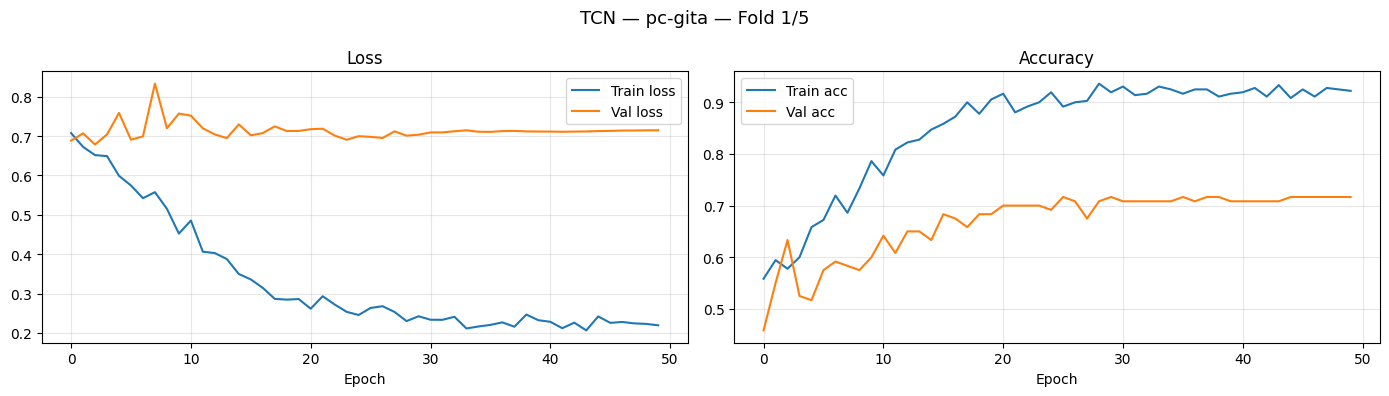

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Pérdida
axes[0].plot(history.history['loss'],     label='Train loss')
axes[0].plot(history.history['val_loss'], label='Val loss')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history.history['accuracy'],     label='Train acc')
axes[1].plot(history.history['val_accuracy'], label='Val acc')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'TCN — {DATASET_NAME} — Fold {FOLD_IDX+1}/{K}', fontsize=13)
plt.tight_layout()
plt.show()

## Evaluación en Validation

## 7. Evaluación en Test

In [31]:
# Predicciones
y_pred_proba = clf.predict(X_test, batch_size=BATCH_SIZE)  # shape (N, 2)
y_pred       = np.argmax(y_pred_proba, axis=1)             # clase predicha
y_true       = y_test_raw                                  # entero (0/1)

# Métricas
acc = accuracy_score(y_true, y_pred)
roc = roc_auc_score(y_true, y_pred_proba[:, 1])

print(f"{'='*50}")
print(f" RESULTADOS — Fold {FOLD_IDX+1}/{K}")
print(f"{'='*50}")
print(f"  Accuracy : {acc:.4f}")
print(f"  ROC-AUC  : {roc:.4f}")
print()
print(classification_report(y_true, y_pred, target_names=['Control', 'Patológicas']))

 RESULTADOS — Fold 1/5
  Accuracy : 0.5417
  ROC-AUC  : 0.5275

              precision    recall  f1-score   support

     Control       0.52      0.90      0.66        60
 Patológicas       0.65      0.18      0.29        60

    accuracy                           0.54       120
   macro avg       0.59      0.54      0.47       120
weighted avg       0.59      0.54      0.47       120



In [33]:
# ── DIAGNÓSTICO: comparar métrica Keras vs sklearn en VALIDACIÓN ──────
y_val_pred_proba = clf.predict(X_val, batch_size=BATCH_SIZE)
y_val_pred = np.argmax(y_val_pred_proba, axis=1)

acc_val_sklearn = accuracy_score(y_val_raw, y_val_pred)
print(f"Val accuracy (sklearn):          {acc_val_sklearn:.4f}")
print(f"Val accuracy (Keras en training): ver logs arriba")
print(f"→ Si difieren mucho, hay un bug de métrica en Keras 3")


Val accuracy (sklearn):          0.6333
Val accuracy (Keras en training): ver logs arriba
→ Si difieren mucho, hay un bug de métrica en Keras 3


## 8. Matriz de Confusión y Curva ROC

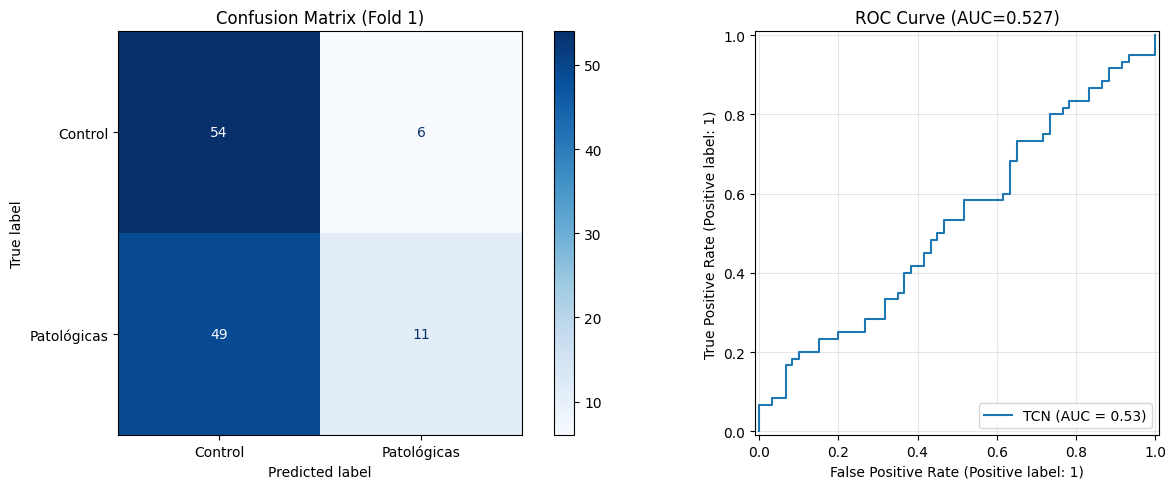

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm   = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Control', 'Patológicas'])
disp.plot(ax=axes[0], cmap='Blues')
axes[0].set_title(f'Confusion Matrix (Fold {FOLD_IDX+1})')

# ROC Curve
RocCurveDisplay.from_predictions(
    y_true, y_pred_proba[:, 1],
    name='TCN',
    ax=axes[1],
)
axes[1].set_title(f'ROC Curve (AUC={roc:.3f})')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. (Opcional) K-Fold Completo

Descomenta para entrenar sobre todos los folds y obtener métricas promedio.  
**⚠ Puede tardar bastante dependiendo de la duración del audio y el hardware.**

In [ ]:
all_accs, all_aucs = [], []

for k in range(K):
    print(f"\n{'='*60}")
    print(f" FOLD {k+1}/{K}")
    print(f"{'='*60}")

    fd = folds[k]
    X_tr, y_tr_raw, X_v, y_v_raw, X_te, y_te_raw = load_fold_data(
        fd, DATA_DIR, TARGET_SR, TARGET_SAMPLES
    )
    y_tr = to_categorical(y_tr_raw, NUM_CLASSES)
    y_v  = to_categorical(y_v_raw,  NUM_CLASSES)

    # Modelo nuevo por fold (pesos frescos)
    clf_k = TCNClassifier(
        input_shape  = (TARGET_SAMPLES,),
        n_classes    = NUM_CLASSES,
        nb_filters   = NB_FILTERS,
        kernel_size  = KERNEL_SIZE,
        dilations    = DILATIONS,
        nb_stacks    = NB_STACKS,
        dropout_rate = DROPOUT_RATE,
        dense_units  = DENSE_UNITS,
    )
    clf_k.model.compile(
        optimizer = OPTIMIZER,
        loss      = tf.keras.losses.CategoricalCrossentropy(),
        metrics   = ['accuracy'],
    )
    clf_k.model.fit(
        X_tr, y_tr,
        validation_data = (X_v, y_v),
        epochs     = EPOCHS,
        batch_size = BATCH_SIZE,
        shuffle    = True,
        callbacks  = callbacks,
        verbose    = 0,
    )

    yp_proba = clf_k.predict(X_te)
    yp       = np.argmax(yp_proba, axis=1)
    acc_k    = accuracy_score(y_te_raw, yp)
    auc_k    = roc_auc_score(y_te_raw, yp_proba[:, 1])
    all_accs.append(acc_k)
    all_aucs.append(auc_k)
    print(f"  → Fold {k+1}: Acc={acc_k:.4f}  AUC={auc_k:.4f}")

print(f"\n{'='*60}")
print(f" RESULTADOS K-FOLD PROMEDIO")
print(f"{'='*60}")
print(f"  Accuracy: {np.mean(all_accs):.4f} ± {np.std(all_accs):.4f}")
print(f"  ROC-AUC:  {np.mean(all_aucs):.4f} ± {np.std(all_aucs):.4f}")